# Laboratorio 3 — Redes Neuronales Recurrentes y LSTM
### CC3092 · Deep Learning y Sistemas Inteligentes

**Problema.** Clasificación binaria de sentimiento (positivo / negativo) sobre **IMDB Reviews**.
A diferencia de los laboratorios anteriores, cada observación es una **secuencia de longitud
variable**, así que buena parte del trabajo está en cómo convertir texto de longitud arbitraria
en tensores rectangulares sin destruir información.

**Qué se compara.** Tres formas de resumir una reseña en un vector de tamaño fijo:

| Modelo | Resumen de la secuencia | ¿Usa el orden de las palabras? |
|---|---|---|
| MLP (baseline) | promedio de los embeddings de los tokens | **No** |
| RNN simple (`nn.RNN`) | último estado oculto $h_T$ | Sí, con memoria frágil |
| LSTM (`nn.LSTM`) | último estado oculto $h_T$, con celda $c_T$ y compuertas | Sí, con memoria protegida |

El código reutilizable vive en [`src/lab3/`](../src/lab3) (`data.py`, `models.py`, `engine.py`,
`experiments.py`, `plots.py`); este notebook lo importa y ejecuta el estudio completo de punta a punta.

## 0. Configuración

In [1]:
import sys, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lab3.data import (PAD_IDX, UNK_IDX, load_raw_splits, make_dataloaders,
                       prepare_corpus, tokenize)
from lab3.models import build_model, count_parameters
from lab3.engine import (ExperimentConfig, confusion, evaluate, get_device,
                         run_experiment, save_results, set_seed)
from lab3.experiments import (ALL_CONFIGS, LSTM_CONFIGS, MLP_CONFIGS, RNN_CONFIGS,
                              LENGTH_EXPERIMENT_LENS)
from lab3 import plots

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110

SEED = 42
set_seed(SEED)
DEVICE = get_device()
print("PyTorch", torch.__version__, "| dispositivo:", DEVICE)

PyTorch 2.13.0+cu130 | dispositivo: cuda


## 1–2. Carga, exploración y preparación de los datos

Cargamos el dataset desde HuggingFace. **Nota práctica:** el alias corto `"imdb"` ya no resuelve
en la versión actual de `datasets` (el Hub exige `namespace/nombre`), así que usamos el id
canónico `stanfordnlp/imdb`. El `DatasetDict` trae además un split `unsupervised` de 50 000
reseñas sin etiqueta que **no** usamos: este laboratorio es supervisado.

In [2]:
from datasets import load_dataset

imdb = load_dataset("stanfordnlp/imdb")
imdb

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

### 2.1 ¿Cuántas observaciones y cuántas clases? ¿Están balanceadas?

In [3]:
raw = load_raw_splits(val_size=5000, seed=SEED)

resumen = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(raw.train_labels), len(raw.val_labels), len(raw.test_labels)],
    "negativas (0)": [int(np.sum(np.array(s) == 0)) for s in
                      (raw.train_labels, raw.val_labels, raw.test_labels)],
    "positivas (1)": [int(np.sum(np.array(s) == 1)) for s in
                      (raw.train_labels, raw.val_labels, raw.test_labels)],
})
resumen["% positivas"] = (resumen["positivas (1)"] / resumen["n"] * 100).round(1)
resumen

,split,n,negativas (0),positivas (1),% positivas
0,train,20000,10000,10000,50.0
1,validation,5000,2500,2500,50.0
2,test,25000,12500,12500,50.0


**Respuesta.** El dataset etiquetado tiene **50 000 observaciones** (25 000 en el split oficial de
train y 25 000 en el de test) y **2 clases** (`0` = negativa, `1` = positiva). Está **perfectamente
balanceado**: 50 % de cada clase en ambos splits.

Ese balance tiene dos consecuencias de diseño:

1. La **accuracy es interpretable** (el azar está en 50 %), pero igual reportamos
   precision / recall / F1 **macro** porque el enunciado los pide y porque revelan si un modelo
   se sesga hacia una clase aunque su accuracy global se vea bien.
2. El split oficial de train viene **ordenado por clase**. Si recortáramos validación tomando los
   últimos 5 000 ejemplos, quedaría 100 % positiva. Por eso `load_raw_splits` baraja con semilla
   fija y hace el corte **estratificado**: 2 500 de cada clase.

**División usada:** 20 000 train / 5 000 validación (ambos del split oficial de train) y las
25 000 reseñas del split de test, que se tocan **una sola vez** al final del laboratorio.

### 2.2 ¿Cuál es la longitud de las reseñas?

In [4]:
# La tokenización se explica en 2.3; aquí ya la necesitamos para medir longitudes en tokens.
corpus = prepare_corpus(max_vocab=20_000, min_freq=2, seed=SEED)
train_lens = np.array([len(s) for s in corpus.train_ids])

estadisticos = pd.Series({
    "mínimo": train_lens.min(),
    "máximo": train_lens.max(),
    "promedio": round(train_lens.mean(), 1),
    "mediana": np.median(train_lens),
    "desv. estándar": round(train_lens.std(), 1),
    "percentil 75": np.percentile(train_lens, 75),
    "percentil 90": np.percentile(train_lens, 90),
    "percentil 95": np.percentile(train_lens, 95),
    "percentil 99": np.percentile(train_lens, 99),
}, name="tokens por reseña (train)")
estadisticos.to_frame()

,tokens por reseña (train)
mínimo,10.00
máximo,2503.00
promedio,235.10
mediana,176.00
desv. estándar,174.20
percentil 75,286.00
percentil 90,459.00
percentil 95,600.00
percentil 99,911.02


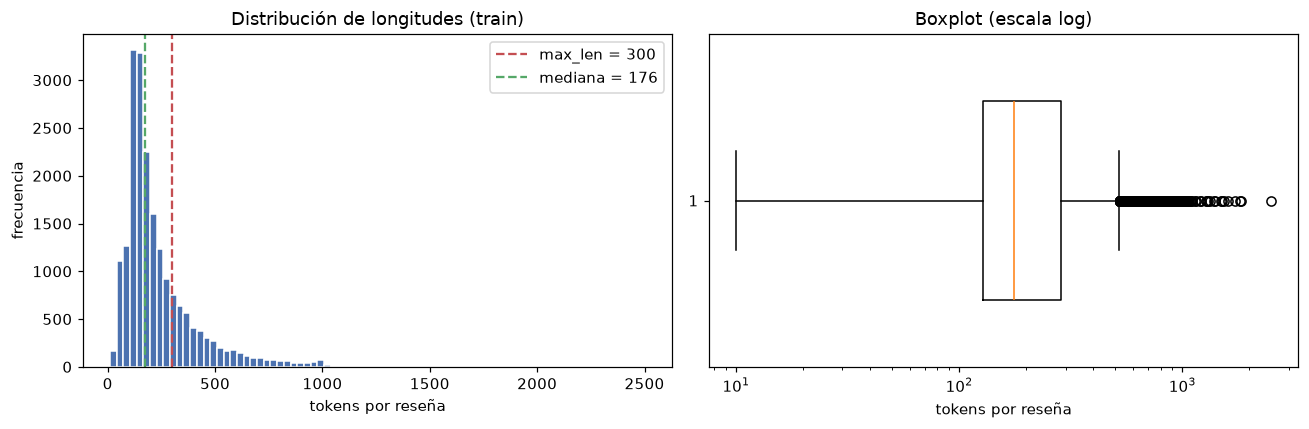

In [5]:
fig = plots.plot_length_distribution(train_lens, max_len=300, filename="01_length_distribution.png")
plt.show()

**Respuesta.** Las reseñas van de **10 a 2 503 tokens**, con **promedio 235** y **mediana 176**.
La distribución tiene una **cola derecha larguísima** (la media supera a la mediana en un 34 %):
la mayoría de reseñas son de un par de párrafos, pero un puñado son ensayos de más de 2 000
palabras. Esa asimetría es exactamente el motivo por el que hace falta truncar — dimensionar los
batches para el caso peor desperdiciaría cómputo en padding para el 99 % de los ejemplos.

### 2.3 Estrategia de tokenización, vocabulario y OOV

**Estrategia elegida: tokenización *word-level* con expresión regular.**

```python
_BR_RE    = re.compile(r"<br\s*/?>")        # IMDB viene con saltos de línea en HTML
_TOKEN_RE = re.compile(r"[a-z0-9']+|[!?]")  # palabras (con apóstrofe) + '!' y '?'
```

Decisiones concretas y su razón:

| Decisión | Razón |
|---|---|
| Minúsculas | `"Great"` y `"great"` son la misma evidencia de sentimiento; duplicarlas dispersa el conteo |
| Eliminar `<br />` | es ruido de formato del scraping original, aparece en ~40 % de las reseñas |
| Conservar `'` dentro de la palabra | `"don't"`, `"isn't"` — la negación es señal fuerte y partirla la destruiría |
| Conservar `!` y `?` como tokens | cargan intensidad emocional; el resto de puntuación se descarta |
| **No** usar subword (BPE/WordPiece) | el objetivo es comparar arquitecturas recurrentes, no tokenizadores; un vocabulario de palabras deja la `nn.Embedding` interpretable y el pipeline sin dependencias extra |

**Vocabulario:** las 20 000 palabras más frecuentes **del split de train** con frecuencia ≥ 2.
Construirlo con validación o test sería *data leakage*: el modelo tendría una entrada dedicada
para palabras que solo existen en los datos de evaluación.

**Manejo de OOV:** dos tokens especiales reservados, `<pad>` = 0 y `<unk>` = 1. Toda palabra fuera
del vocabulario se mapea a `<unk>`; el modelo aprende un embedding para "palabra rara" en lugar de
fallar. `<pad>` se pasa como `padding_idx` a `nn.Embedding`, con lo que su vector queda fijo en
cero y **no recibe gradiente**.

In [6]:
from collections import Counter

tipos_totales = len(Counter(t for toks in corpus.train_tokens for t in toks))
oov = lambda seqs: 100 * sum(sum(1 for t in s if t == UNK_IDX) for s in seqs) / sum(len(s) for s in seqs)

print(f"Tipos (palabras distintas) en train : {tipos_totales:,}")
print(f"Tamaño del vocabulario retenido     : {corpus.vocab_size:,}  "
      f"({100*corpus.vocab_size/tipos_totales:.1f}% de los tipos)")
print(f"Tasa de OOV (<unk>) en train         : {oov(corpus.train_ids):.2f}% de los tokens")
print(f"Tasa de OOV (<unk>) en test          : {oov(corpus.test_ids):.2f}% de los tokens")
print()
print("Primeras entradas del vocabulario:", list(corpus.vocab.items())[:12])

Tipos (palabras distintas) en train : 79,124
Tamaño del vocabulario retenido     : 20,000  (25.3% de los tipos)
Tasa de OOV (<unk>) en train         : 2.75% de los tokens
Tasa de OOV (<unk>) en test          : 3.49% de los tokens

Primeras entradas del vocabulario: [('<pad>', 0), ('<unk>', 1), ('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('in', 8), ('it', 9), ('i', 10), ('this', 11)]


**Lectura.** Nos quedamos con **20 000 de 79 124 tipos** (25 %) y aun así solo **2.75 %** de los
tokens de train caen en `<unk>`: la ley de Zipf trabaja a nuestro favor, la cola larga que
descartamos son palabras que aparecen una o dos veces (nombres propios, erratas) de las que un
modelo no podría aprender nada útil de todos modos. En test la tasa sube a **3.49 %**, que es la
diferencia esperable por vocabulario no visto — pequeña y sin impacto práctico.

Guardar esas 59 000 palabras extra habría costado ~7.6 M de parámetros adicionales solo en la
capa de embedding, más que triplicando el tamaño de los modelos, a cambio de un 2.75 % de tokens.

### 2.4 ¿Por qué padding y/o truncamiento? ¿Qué `max_len` elegimos?

**Por qué padding.** Un batch es un tensor `(batch, tiempo)` — un **rectángulo**. Las reseñas de un
mismo batch miden 40, 176 y 900 tokens, así que hay que rellenar las cortas hasta la más larga del
batch con `<pad>` para poder apilarlas. Sin eso solo podríamos entrenar con `batch_size=1`, lo que
desperdicia por completo el paralelismo de la GPU.

Usamos **padding dinámico por batch** (`pad_sequence` dentro del `collate_fn`), no padding a una
longitud global fija: cada batch se rellena solo hasta *su* reseña más larga, lo que reduce
bastante el cómputo desperdiciado.

**Por qué truncamiento.** El padding resuelve la forma del tensor pero no el costo: con reseñas de
hasta 2 503 tokens, un batch desafortunado obligaría a la recurrente a dar 2 503 pasos secuenciales
(que **no** se paralelizan) y a retropropagar por todos ellos. Truncar acota el peor caso y, en la
práctica, además ayuda: el sentimiento de una reseña suele estar declarado bastante antes del final.

**`max_len = 300` para la rejilla principal.** Justificación cuantitativa abajo: cubre el **77 %**
de las reseñas completas y el **81 %** de todos los tokens del corpus, a un tercio del costo del
peor caso. En la sección 4.1 estudiamos explícitamente qué se gana y qué se pierde con 50, 200 y 500.

In [7]:
cobertura = pd.DataFrame([
    {"max_len": L,
     "% reseñas completas": round(100 * (train_lens <= L).mean(), 1),
     "% de tokens conservados": round(100 * np.minimum(train_lens, L).sum() / train_lens.sum(), 1),
     "pasos de tiempo (peor caso)": L}
    for L in (50, 100, 200, 300, 500, 1000)
])
cobertura

,max_len,% reseñas completas,% de tokens conservados,pasos de tiempo (peor caso)
0,50,2.3,21.2,50
1,100,11.9,41.0,100
2,200,58.2,68.1,200
3,300,77.0,81.4,300
4,500,92.0,93.4,500
5,1000,99.7,99.8,1000


### 2.5 Cinco ejemplos del dataset

In [8]:
rng = np.random.default_rng(SEED)
muestras = rng.choice(len(raw.train_texts), size=5, replace=False)

for i, idx in enumerate(muestras, 1):
    texto = raw.train_texts[idx]
    tokens = tokenize(texto)
    etiqueta = "POSITIVA" if raw.train_labels[idx] == 1 else "NEGATIVA"
    print(f"--- Ejemplo {i} | etiqueta: {etiqueta} | {len(tokens)} tokens "
          f"| {len(texto)} caracteres ---")
    print(texto[:400].replace("<br />", " ") + ("..." if len(texto) > 400 else ""))
    print(f"tokens[:15] = {tokens[:15]}")
    print()

--- Ejemplo 1 | etiqueta: POSITIVA | 63 tokens | 330 caracteres ---
With the current trend of gross out humor, this film is the granddaddy of them all. While some of the humor is dated, every skit will either shock, repulse, or make you laugh out loud. Most memorable is the sex games commentary and, of course, the VD commercial. It doesn't always work, but pays off when it does. I give this a 7.
tokens[:15] = ['with', 'the', 'current', 'trend', 'of', 'gross', 'out', 'humor', 'this', 'film', 'is', 'the', 'granddaddy', 'of', 'them']

--- Ejemplo 2 | etiqueta: NEGATIVA | 179 tokens | 1006 caracteres ---
I wanted to like this film, I really did. It's got some good actors but ultimately it falls flat. It tries too hard to be funny in some places (the daughters over zealous cooking attempts), over reaches in others (the scene where they clean up someone's yard, so he agrees to join the team) and has some scenes that, while mildly interesting, are really just filler (all the work scene's). An

### 2.6 El `DataLoader` en acción

Comprobamos que el `collate_fn` hace lo prometido: rellena hasta la reseña más larga **del batch**
y devuelve las longitudes reales, que son las que después alimentan a `pack_padded_sequence`.

In [9]:
demo = make_dataloaders(corpus, max_len=300, batch_size=8, seed=SEED)
x, lengths, y = next(iter(demo["train"]))

print("x         :", tuple(x.shape), "  (batch, tiempo)")
print("lengths   :", lengths.tolist())
print("etiquetas :", y.tolist())
print(f"\nPadding en este batch: {(x == PAD_IDX).float().mean()*100:.1f}% de las celdas son <pad>")
print("Última fila (reseña más corta), últimos 15 pasos:", x[lengths.argmin()][-15:].tolist())

x         : (8, 300)   (batch, tiempo)
lengths   : [213, 234, 136, 295, 300, 300, 104, 43]
etiquetas : [0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0]

Padding en este batch: 32.3% de las celdas son <pad>
Última fila (reseña más corta), últimos 15 pasos: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


---
## 3. Investigación: capas de PyTorch para RNN y LSTM

### 3.1 `nn.Embedding`

**Propósito.** Tabla de búsqueda entrenable que convierte un id entero de token en un vector denso
de dimensión `embedding_dim`. Es matemáticamente equivalente a multiplicar un one-hot de tamaño
`|V|` por una matriz `|V| × d`, pero implementado como indexación (sin construir el one-hot), que
es órdenes de magnitud más barato. Sustituye una representación dispersa y ortogonal (donde
`"good"` y `"great"` están igual de lejos que `"good"` y `"tractor"`) por una geométrica, donde la
distancia se aprende de los datos.

| Parámetro | Qué hace |
|---|---|
| `num_embeddings` | tamaño del vocabulario (filas de la tabla) |
| `embedding_dim` | dimensión del vector de cada token (columnas) |
| `padding_idx` | id cuyo embedding se **inicializa en cero y nunca recibe gradiente**; lo usamos con `<pad>` = 0 para que el relleno no aporte señal |
| `max_norm`, `norm_type` | renormalizan los embeddings que superen cierta norma (regularización, no la usamos) |
| `freeze` (vía `from_pretrained`) | permite cargar vectores preentrenados (GloVe, word2vec) y congelarlos |

Es, con diferencia, la capa con más parámetros de nuestros modelos: `20 000 × 128 = 2.56 M`,
frente a los ~132 K de una `nn.LSTM` de 128 unidades. Esto será clave para leer la tabla de
parámetros de la sección 5.

### 3.2 `nn.RNN`

**Propósito.** Recurrencia de Elman: recorre la secuencia paso a paso aplicando la misma
transformación afín a la entrada actual y al estado anterior,

$$h_t = \tanh(W_{ih}\,x_t + b_{ih} + W_{hh}\,h_{t-1} + b_{hh})$$

Los pesos se **comparten en todos los pasos de tiempo**: por eso maneja longitudes variables con
un número fijo de parámetros, y por eso el gradiente acaba multiplicando repetidamente por la
misma matriz $W_{hh}$ (origen del vanishing/exploding gradient, sección 3.7).

| Parámetro | Qué hace |
|---|---|
| `input_size` / `hidden_size` | dimensión de $x_t$ y de $h_t$ |
| `num_layers` | RNNs apiladas: la salida de una es la entrada de la siguiente |
| `nonlinearity` | `'tanh'` (por defecto) o `'relu'` |
| `batch_first` | si `True`, los tensores son `(batch, tiempo, features)` en vez de `(tiempo, batch, features)` |
| `dropout` | dropout **entre capas apiladas**; no hace nada si `num_layers=1` |
| `bidirectional` | duplica la recurrencia (una hacia adelante, otra hacia atrás) y concatena |

**Salidas:** `output` (el estado oculto de *cada* paso, `(B, T, H)`) y `h_n` (el estado final de
cada capa, `(num_layers * num_directions, B, H)`). Para nuestra arquitectura **many-to-one**
tomamos `h_n[-1]`: el estado de la última capa tras consumir el último token.

### 3.3 `nn.LSTM`

**Propósito.** Misma interfaz que `nn.RNN`, pero cada paso mantiene **dos** estados —el oculto
$h_t$ y el de celda $c_t$— y tres compuertas que regulan el flujo de información:

$$
f_t = \sigma(W_f[h_{t-1},x_t]+b_f) \quad
i_t = \sigma(W_i[h_{t-1},x_t]+b_i) \quad
o_t = \sigma(W_o[h_{t-1},x_t]+b_o)
$$
$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
\qquad
h_t = o_t \odot \tanh(c_t)
$$

Los parámetros son los mismos que en `nn.RNN` salvo `nonlinearity` (fija). Tiene **4× más
parámetros** que una RNN del mismo `hidden_size`, porque cada una de las cuatro transformaciones
(las tres compuertas más el candidato $\tilde{c}_t$) tiene su propio par de matrices.

**Salidas:** `output` y la tupla `(h_n, c_n)`. Por eso nuestro código hace
`h_n = hidden[0] if isinstance(hidden, tuple) else hidden`: la única diferencia de manejo entre
`nn.RNN` y `nn.LSTM` en un clasificador many-to-one.

### 3.4 `pad_sequence`, `pack_padded_sequence` y `pad_packed_sequence`

* **`pad_sequence(seqs, batch_first, padding_value)`** — recibe una lista de tensores 1-D de
  longitudes distintas y devuelve un tensor rectangular `(B, T_max)` rellenado. Es lo que usamos
  dentro del `collate_fn` para armar el batch.
* **`pack_padded_sequence(padded, lengths, batch_first, enforce_sorted)`** — convierte el
  rectángulo en un `PackedSequence`: los tokens reales aplanados junto con cuántas secuencias
  siguen "vivas" en cada paso de tiempo. La recurrente entonces **salta los `<pad>`**.
  `enforce_sorted=False` deja que PyTorch ordene internamente y no obliga a ordenar el batch.
* **`pad_packed_sequence(packed, batch_first)`** — la operación inversa, para volver al tensor
  rectangular. Solo hace falta si se necesitan las salidas de todos los pasos (atención,
  etiquetado secuencial); en un many-to-one que usa `h_n` no se llega a usar.

**Por qué es imprescindible aquí.** Sin *packing*, la recurrente procesaría los `<pad>` como si
fueran palabras: en una reseña de 40 tokens dentro de un batch de 300, el "último estado oculto"
sería el resultado de digerir 260 pasos de relleno, y la señal real quedaría diluida o
sobrescrita. Con `pack_padded_sequence`, `h_n` es literalmente el estado tras el **último token
real** de cada reseña. Lo demostramos numéricamente abajo.

### 3.5 `torch.nn.utils.clip_grad_norm_`

**Propósito.** Calcula la norma global del gradiente de todos los parámetros y, si supera
`max_norm`, reescala **todos** los gradientes por el mismo factor. Preserva la dirección del paso
y solo acota su magnitud.

| Parámetro | Qué hace |
|---|---|
| `parameters` | iterable de tensores con `.grad` |
| `max_norm` | umbral de la norma (usamos 1.0) |
| `norm_type` | 2 por defecto (norma euclídea) |

Es la defensa estándar contra el **exploding gradient**. Se llama **después de `loss.backward()`
y antes de `optimizer.step()`** — si se llama después del `step`, no tiene efecto sobre esa
actualización. En una RNN simple sobre 300 pasos, un solo batch con gradiente explotado puede
mandar los pesos a una región de la que el entrenamiento ya no se recupera; en la sección 4 se
ve el efecto medido.

### 3.6 `nn.Dropout` en capas recurrentes

Hay un matiz importante: el argumento `dropout=` de `nn.RNN`/`nn.LSTM` **solo aplica dropout entre
capas apiladas**, así que con `num_layers=1` PyTorch incluso emite un warning y no hace nada. Y no
se puede aplicar dropout independiente en cada paso de tiempo de la recurrencia sin romper la
memoria: máscaras distintas por paso inyectan ruido que se acumula a lo largo de la secuencia.

Por eso en `_RecurrentClassifier` aplicamos dropout **donde sí es seguro**:

1. `embed_dropout` — sobre los embeddings, antes de entrar a la recurrencia.
2. `out_dropout` — sobre $h_T$, antes de la capa lineal de salida.

Y además pasamos `dropout=dropout if num_layers > 1 else 0.0` a la capa recurrente, para
aprovechar el dropout entre capas cuando sí hay más de una.

### 3.7 Conceptos

**Estado oculto vs. estado de celda.** El **estado de celda** $c_t$ es la memoria de largo plazo:
se actualiza de forma **aditiva** ($c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$), como una
cinta transportadora en la que la información puede viajar muchos pasos casi intacta si la
compuerta de olvido lo permite. El **estado oculto** $h_t$ es la vista filtrada de esa memoria que
se expone al exterior en cada paso ($h_t = o_t \odot \tanh(c_t)$): es lo que ven la siguiente capa
y el clasificador. Una RNN simple solo tiene $h_t$, y por eso su memoria y su salida son la misma
cosa — no puede "recordar algo sin usarlo ahora mismo".

**Vanishing / exploding gradient.** Al retropropagar por el tiempo (BPTT), el gradiente respecto a
un paso lejano incluye un producto de $T$ jacobianos:
$\frac{\partial h_T}{\partial h_k} = \prod_{t=k+1}^{T} W_{hh}^\top \operatorname{diag}(\tanh'(\cdot))$.
Ese producto es esencialmente una potencia de una matriz: si su radio espectral (multiplicado por
$|\tanh'| \le 1$) es menor que 1, el gradiente **se desvanece exponencialmente** en $T$ y los pasos
lejanos dejan de recibir señal de aprendizaje; si es mayor que 1, **explota**. Es exponencial en la
longitud, de ahí que sea mucho más severo en secuencias largas: con $T=50$ un factor de 0.9 por
paso deja un 0.5 % del gradiente, pero con $T=300$ deja $10^{-14}$ — numéricamente cero.

**Cómo ayudan las compuertas.** La ruta $c_{t-1} \to c_t$ es una **suma con una multiplicación
elemento a elemento por $f_t$**, no una multiplicación por una matriz de pesos. La derivada por esa
ruta es simplemente $f_t$, y si la compuerta de olvido aprende a estar cerca de 1, el gradiente se
propaga casi sin atenuación a través de muchos pasos: es un "camino de gradiente constante" análogo
a una conexión residual. Además las compuertas son **aprendidas y dependientes de la entrada**: la
red decide qué conservar (`i`), qué descartar (`f`) y qué exponer (`o`) según el contenido, en lugar
de aplicar la misma transformación a todo. El exploding gradient no lo resuelven — para eso está el
gradient clipping —, pero el vanishing sí queda muy mitigado.

### 3.8 Demostración: por qué `pack_padded_sequence` no es opcional

Pasamos el **mismo** batch por la misma LSTM, con y sin empaquetar, y comparamos el estado oculto
final de la secuencia más corta.

In [10]:
set_seed(SEED)
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence

lstm_demo = nn.LSTM(8, 4, batch_first=True)
secuencias = [torch.randn(3, 8), torch.randn(12, 8)]      # una corta y una larga
longitudes = torch.tensor([3, 12])
batch_pad = pad_sequence(secuencias, batch_first=True)     # (2, 12, 8)

# (a) sin packing: la LSTM consume los 9 pasos de ceros de la secuencia corta
h_sin = lstm_demo(batch_pad)[1][0][-1]

# (b) con packing: la LSTM se detiene en el último paso real de cada secuencia
empaquetado = pack_padded_sequence(batch_pad, longitudes, batch_first=True, enforce_sorted=False)
h_con = lstm_demo(empaquetado)[1][0][-1]

# (c) referencia: la secuencia corta procesada sola, sin padding en absoluto
h_ref = lstm_demo(secuencias[0].unsqueeze(0))[1][0][-1]

print("h_T secuencia corta, SIN packing :", h_sin[0].detach().numpy().round(4))
print("h_T secuencia corta, CON packing :", h_con[0].detach().numpy().round(4))
print("h_T procesada sola (referencia)  :", h_ref[0].detach().numpy().round(4))
print()
print(f"error |sin packing - referencia| = {(h_sin[0]-h_ref[0]).abs().max():.4f}")
print(f"error |con packing - referencia| = {(h_con[0]-h_ref[0]).abs().max():.6f}")

h_T secuencia corta, SIN packing : [-0.1642 -0.2026  0.2283 -0.04  ]
h_T secuencia corta, CON packing : [-0.2162 -0.0599 -0.0369  0.0971]
h_T procesada sola (referencia)  : [-0.2162 -0.0599 -0.0369  0.0971]

error |sin packing - referencia| = 0.2653
error |con packing - referencia| = 0.000000


**Conclusión de la demostración.** Con packing el resultado es idéntico (hasta precisión numérica)
a procesar la reseña sola; sin packing, el estado final es un vector distinto — la LSTM siguió
actualizando su estado durante 9 pasos de relleno. En un batch real donde conviven reseñas de 40 y
de 300 tokens, ese arrastre es masivo. **Todos nuestros modelos recurrentes usan packing.**

---
## 4. Construcción y entrenamiento de las arquitecturas

Las tres arquitecturas están en [`src/lab3/models.py`](../src/lab3/models.py). Comparten
deliberadamente el mismo front-end (`nn.Embedding` con `padding_idx=0`) y la misma cabeza
(una lineal a **un solo logit**, entrenada con `BCEWithLogitsLoss`, que es numéricamente más
estable que `Sigmoid` + `BCELoss` porque aplica el truco log-sum-exp internamente). Lo único que
cambia entre ellas es **cómo se resume la secuencia**, que es justo la variable de interés.

* **`MLPBaseline`** — promedia los embeddings de los tokens reales (máscara a partir del padding,
  para que las reseñas cortas no queden atenuadas por dividir entre la longitud del batch) y pasa
  el resultado por un MLP. **Descarta el orden por completo**: `"good, not bad"` y `"bad, not good"`
  producen exactamente el mismo vector.
* **`SimpleRNNClassifier`** — `nn.RNN` sobre la secuencia empaquetada, clasificando desde `h_n[-1]`.
* **`LSTMClassifier`** — idéntico pero con `nn.LSTM`, para que la **única** diferencia con la RNN
  sean las compuertas.

In [11]:
for kind, kwargs in [("mlp", {"embed_dim": 128, "hidden_dims": (256, 128)}),
                     ("rnn", {"embed_dim": 128, "hidden_dim": 128}),
                     ("lstm", {"embed_dim": 128, "hidden_dim": 128})]:
    modelo = build_model(kind, corpus.vocab_size, **kwargs)
    emb = count_parameters(modelo.embedding)
    total = count_parameters(modelo)
    print(f"{kind.upper():<5} total {total:>10,}  |  embedding {emb:>10,} ({100*emb/total:.1f}%)"
          f"  |  resto {total-emb:>8,}")
print()
print(build_model("lstm", corpus.vocab_size))

MLP   total  2,626,049  |  embedding  2,560,000 (97.5%)  |  resto   66,049
RNN   total  2,593,153  |  embedding  2,560,000 (98.7%)  |  resto   33,153
LSTM  total  2,692,225  |  embedding  2,560,000 (95.1%)  |  resto  132,225

LSTMClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (embed_dropout): Dropout(p=0.3, inplace=False)
  (out_dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (rnn): LSTM(128, 128, batch_first=True)
)


**Observación que condiciona toda la comparación de la sección 5:** entre el **95 % y el 99 %** de
los parámetros de cualquiera de los tres modelos están en la capa de embedding, que es idéntica en
los tres. La parte que realmente distingue a las arquitecturas (el MLP, la recurrencia, las
compuertas) son decenas de miles de parámetros sobre 2.6 millones. Comparar modelos "por número
de parámetros" aquí es engañoso si no se separa esa contribución.

### 4.1 La rejilla de iteraciones

15 iteraciones, 5 por arquitectura, definidas en
[`src/lab3/experiments.py`](../src/lab3/experiments.py). El criterio de diseño fue
**cambiar una cosa a la vez** partiendo de una configuración base por arquitectura. Una búsqueda
aleatoria daría mejores números finales, pero no permitiría responder la pregunta de la sección 6
("¿qué hiperparámetro tuvo el mayor impacto?"), que exige poder atribuir cada movimiento de la
métrica a un cambio concreto.

Elementos comunes a todas las iteraciones:

* **Optimizador Adam** y `BCEWithLogitsLoss`; `max_len = 300`; `batch_size = 64`; semilla 42.
* **Early stopping sobre `val_loss`** con `patience` 3–4, restaurando los pesos del mejor epoch.
  Seleccionamos por `val_loss` y no por accuracy porque la pérdida detecta el sobreajuste antes:
  el modelo empieza a estar *más seguro de sus errores* mientras la accuracy sigue plana.
* Las métricas de validación se calculan **en cada epoch**, y se reporta el epoch seleccionado.

In [12]:
pd.DataFrame([{"iteración": c.name, "lr": c.lr, "weight_decay": c.weight_decay,
               "clip_grad": c.clip_grad, "max_len": c.max_len, "epochs (máx.)": c.epochs,
               **c.model_kwargs, "qué cambia": c.note}
              for c in ALL_CONFIGS]).fillna("—").set_index("iteración")

,lr,weight_decay,clip_grad,max_len,epochs (máx.),embed_dim,hidden_dims,dropout,qué cambia,hidden_dim,bidirectional
iteración,,,,,,,,,,,
mlp-01-base,0.0010,0.00000,—,300,10,64,"(64,)",0.0,"base: embeddings pequeños, una capa oculta, si...",—,—
mlp-02-capacidad,0.0010,0.00000,—,300,10,128,"(256, 128)",0.0,"+capacidad: embed 64->128 y cabeza (256,128); ...",—,—
mlp-03-dropout,0.0010,0.00000,—,300,12,128,"(256, 128)",0.5,misma capacidad que 02 + dropout 0.5: ¿control...,—,—
mlp-04-weight-decay,0.0010,0.00010,—,300,12,128,"(256, 128)",0.5,03 + weight decay 1e-4: segunda vía de regular...,—,—
mlp-05-lr-alto,0.0100,0.00000,—,300,10,128,"(256, 128)",0.5,03 con lr 1e-3 -> 1e-2: sonda del impacto nega...,—,—
rnn-01-base,0.0010,0.00000,—,300,20,128,—,0.0,"base: 1 capa, sin dropout ni clipping",128.0,—
rnn-02-clip,0.0010,0.00000,1.0,300,20,128,—,0.0,base + gradient clipping 1.0: el BPTT de una R...,128.0,—
rnn-03-lr-bajo,0.0003,0.00000,1.0,300,20,128,—,0.0,02 con lr 1e-3 -> 3e-4: pasos más pequeños par...,128.0,—
rnn-04-hidden-256,0.0003,0.00000,1.0,300,20,128,—,0.3,03 + hidden 128->256 y dropout 0.3: más memori...,256.0,—


### 4.2 Entrenamiento de las 15 iteraciones

Cada iteración imprime su curva epoch a epoch (pérdida de train, pérdida de validación y métricas
de clasificación sobre validación). En una RTX 4050 el bloque completo tarda ~13 minutos.

In [13]:
t0 = time.time()
resultados = []
for i, config in enumerate(ALL_CONFIGS, 1):
    print(f"\n[{i}/{len(ALL_CONFIGS)}] {config.name} — {config.note}")
    resultados.append(run_experiment(config, corpus, device=DEVICE))
save_results(resultados, ROOT / "results" / "iterations.json")
print(f"\nTiempo total: {(time.time()-t0)/60:.1f} min")


[1/15] mlp-01-base — base: embeddings pequeños, una capa oculta, sin regularización


  [mlp-01-base] epoch  1 | train 0.5642 | val 0.4248 | acc 0.8140 | f1 0.8139


  [mlp-01-base] epoch  2 | train 0.3462 | val 0.3490 | acc 0.8528 | f1 0.8528


  [mlp-01-base] epoch  3 | train 0.2672 | val 0.3269 | acc 0.8678 | f1 0.8678


  [mlp-01-base] epoch  4 | train 0.2149 | val 0.3216 | acc 0.8724 | f1 0.8723


...

  [lstm-05-bidireccional] epoch  7 | train 0.3117 | val 0.3438 | acc 0.8704 | f1 0.8700


  [lstm-05-bidireccional] epoch  8 | train 0.2795 | val 0.3632 | acc 0.8694 | f1 0.8688


  [lstm-05-bidireccional] epoch  9 | train 0.2417 | val 0.3523 | acc 0.8710 | f1 0.8703


  [lstm-05-bidireccional] epoch 10 | train 0.2178 | val 0.3817 | acc 0.8836 | f1 0.8834


  [lstm-05-bidireccional] epoch 11 | train 0.1975 | val 0.3555 | acc 0.8850 | f1 0.8848
  [lstm-05-bidireccional] early stopping en epoch 11

Tiempo total: 9.1 min


### 4.3 Tabla de resultados de las iteraciones

In [14]:
tabla = pd.DataFrame([{
    "iteración": r["name"],
    "arquitectura": r["kind"].upper(),
    "params": r["n_params"],
    "epoch elegido": f"{r['best_epoch']}/{r['epochs_run']}",
    "val_loss": round(r["val_loss"], 4),
    "accuracy": round(r["val_metrics"]["accuracy"], 4),
    "precision": round(r["val_metrics"]["precision"], 4),
    "recall": round(r["val_metrics"]["recall"], 4),
    "f1": round(r["val_metrics"]["f1"], 4),
    "tiempo (s)": round(r["train_time_s"], 1),
} for r in resultados]).set_index("iteración")
tabla

,arquitectura,params,epoch elegido,val_loss,accuracy,precision,recall,f1,tiempo (s)
iteración,,,,,,,,,
mlp-01-base,MLP,1284225,4/7,0.3216,0.8724,0.8733,0.8724,0.8723,4.4
mlp-02-capacidad,MLP,2626049,3/6,0.3172,0.8768,0.8770,0.8768,0.8768,4.8
mlp-03-dropout,MLP,2626049,4/7,0.3172,0.8748,0.8752,0.8748,0.8748,5.7
mlp-04-weight-decay,MLP,2626049,7/10,0.3061,0.8764,0.8765,0.8764,0.8764,8.4
mlp-05-lr-alto,MLP,2626049,1/4,0.3002,0.8814,0.8816,0.8814,0.8814,3.3
rnn-01-base,RNN,2593153,6/10,0.5849,0.7140,0.7223,0.7140,0.7113,29.1
rnn-02-clip,RNN,2593153,4/8,0.5302,0.7514,0.7520,0.7514,0.7513,28.2
rnn-03-lr-bajo,RNN,2593153,12/16,0.4556,0.8160,0.8167,0.8160,0.8159,57.5
rnn-04-hidden-256,RNN,2659073,16/20,0.4678,0.7980,0.7982,0.7980,0.7980,71.8


In [15]:
# Mejor iteración de cada arquitectura según val_loss (criterio de selección declarado arriba)
mejores = {}
for r in resultados:
    if r["kind"] not in mejores or r["val_loss"] < mejores[r["kind"]]["val_loss"]:
        mejores[r["kind"]] = r

for kind, r in mejores.items():
    print(f"{kind.upper():<5} -> {r['name']:<22} val_loss {r['val_loss']:.4f} "
          f"| val_acc {r['val_metrics']['accuracy']:.4f}")

MLP   -> mlp-05-lr-alto         val_loss 0.3002 | val_acc 0.8814
RNN   -> rnn-03-lr-bajo         val_loss 0.4556 | val_acc 0.8160
LSTM  -> lstm-04-hidden-256     val_loss 0.3354 | val_acc 0.8710


### 4.4 Curvas de pérdida (9+ iteraciones)

Una figura por arquitectura, con las 5 iteraciones lado a lado. La línea punteada marca el epoch
seleccionado por early stopping.

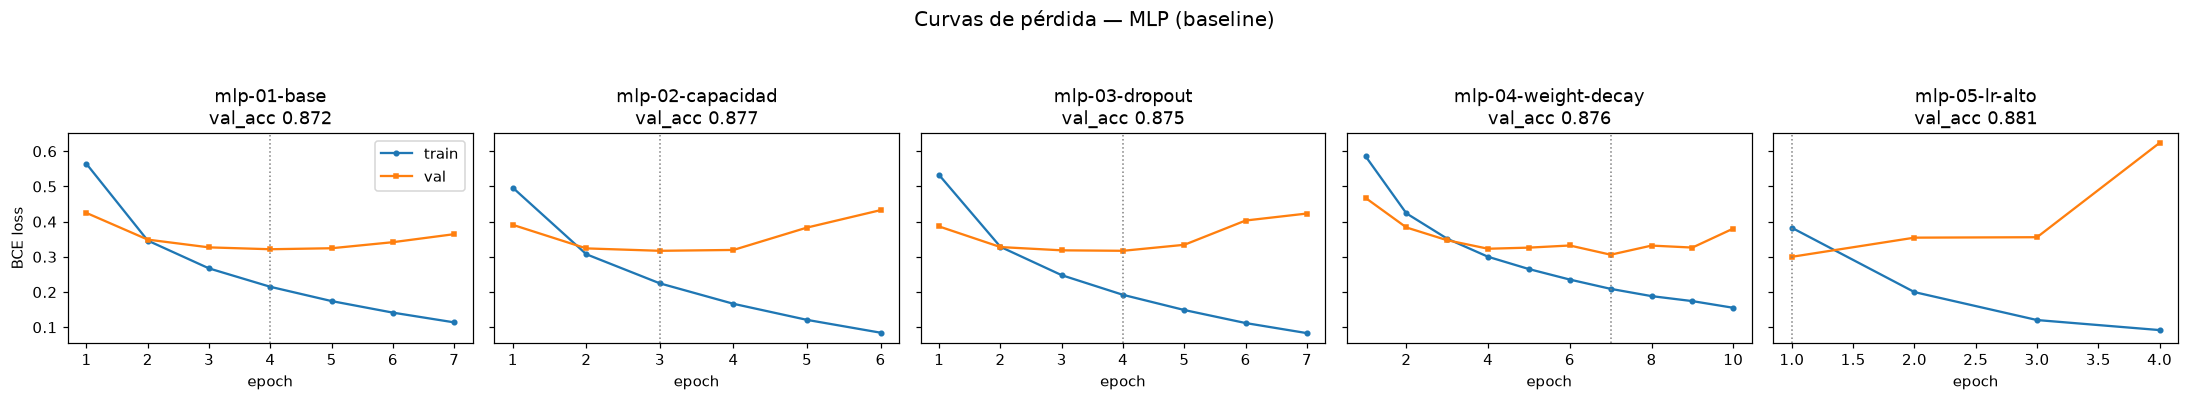

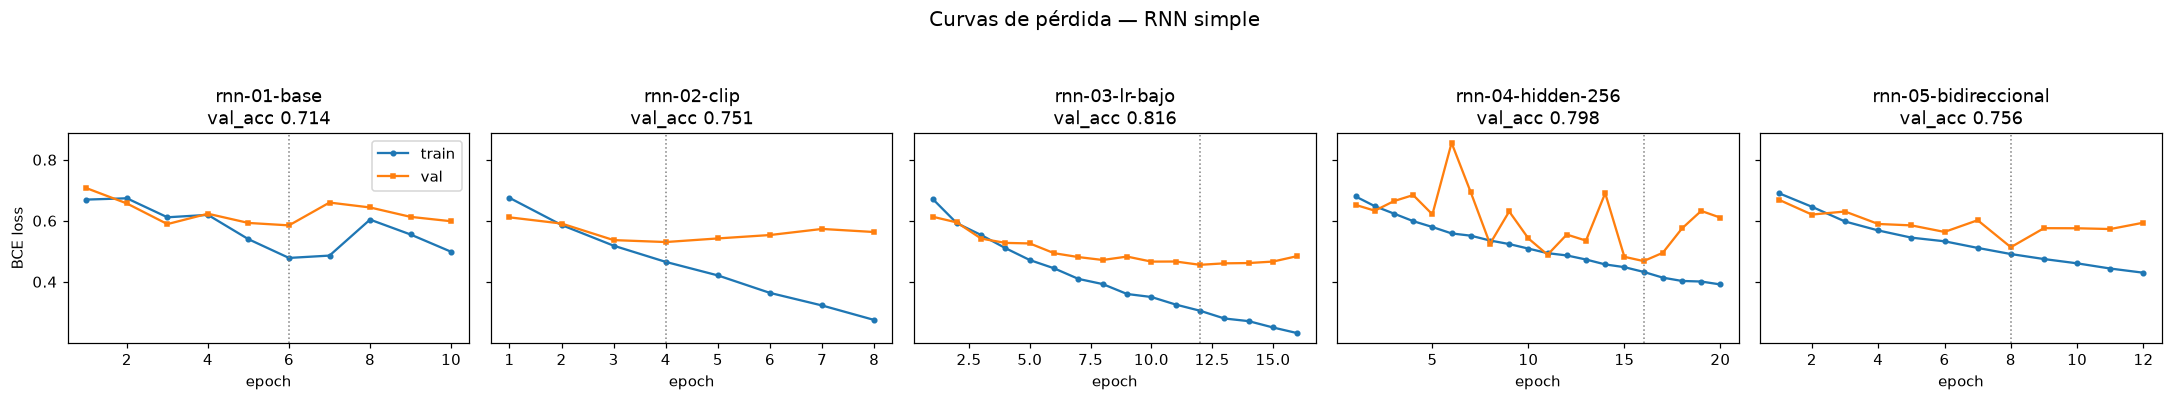

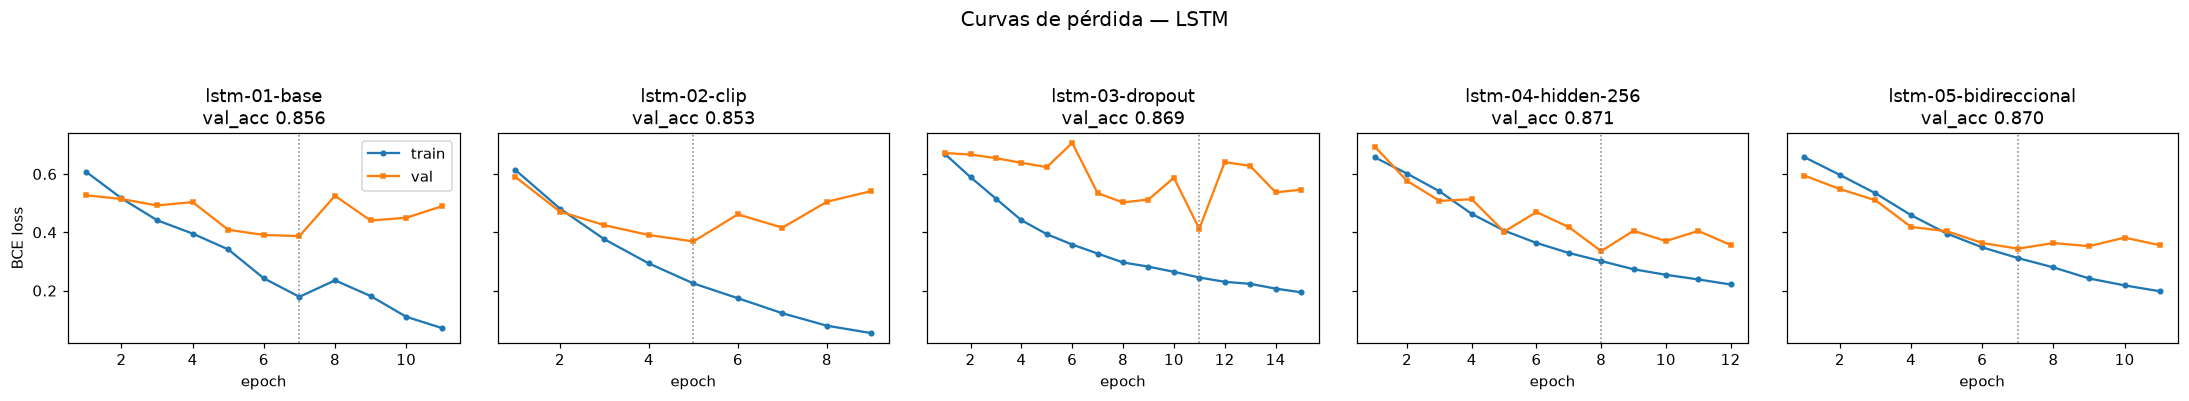

In [16]:
for kind, nombre in [("mlp", "02_curvas_mlp.png"), ("rnn", "03_curvas_rnn.png"),
                     ("lstm", "04_curvas_lstm.png")]:
    plots.plot_loss_curves(resultados, kind, filename=nombre)
    plt.show()

**Lectura de las curvas.**

* **MLP** — sobreajuste rápido y clásico: la pérdida de train baja sin freno mientras la de
  validación toca fondo hacia el epoch 3–4 y repunta. Es lo esperable en un modelo con 2.6 M de
  parámetros y 20 000 ejemplos donde casi toda la capacidad está en la tabla de embeddings, que
  puede memorizar palabras concretas del set de entrenamiento. El dropout retrasa el punto de
  quiebre pero no lo elimina.
* **RNN** — el patrón opuesto: **underfitting**, con curvas ruidosas y no monótonas. `rnn-01`
  llega apenas a 0.71 de accuracy y su pérdida de validación oscila de epoch a epoch; se ve
  literalmente la inestabilidad del BPTT sobre 300 pasos. Con clipping y `lr` más bajo la curva se
  suaviza y baja mucho más, pero necesita el doble de epochs para llegar a donde el MLP llegó en 3.
* **LSTM** — la única con curvas de forma "sana": descenso sostenido en train y en validación,
  con el mínimo de validación bastante más abajo que el de la RNN, y sobreajuste que aparece
  después (y más suave) que en el MLP.

---
## 4.1 (enunciado) Experimento adicional: efecto de la longitud de secuencia

Tomamos la **mejor configuración de la RNN y de la LSTM** y la reentrenamos cambiando
**únicamente** `max_len` ∈ {50, 200, 500}, de modo que cualquier diferencia sea atribuible al
contexto disponible y no a los hiperparámetros. Añadimos el punto intermedio de 200 al mínimo de
dos que pide el enunciado, para poder ver la *tendencia* y no solo los extremos.

In [17]:
from dataclasses import replace

configs_por_nombre = {c.name: c for c in ALL_CONFIGS}
resultados_longitud = []

for kind in ("rnn", "lstm"):
    base = configs_por_nombre[mejores[kind]["name"]]
    print(f"\n=== Mejor {kind.upper()}: {base.name} ===")
    for max_len in LENGTH_EXPERIMENT_LENS:
        print(f"  -> max_len = {max_len}")
        r = run_experiment(replace(base, name=f"{base.name}@len{max_len}", max_len=max_len),
                           corpus, device=DEVICE, verbose=False)
        r["max_len"] = max_len
        resultados_longitud.append(r)
        print(f"     val_loss {r['val_loss']:.4f} | val_acc {r['val_metrics']['accuracy']:.4f} "
              f"| {r['train_time_s']:.1f}s")

(ROOT / "results" / "length_experiment.json").write_text(
    json.dumps([{k: v for k, v in r.items() if k != "model"} for r in resultados_longitud],
               indent=2, ensure_ascii=False))


=== Mejor RNN: rnn-03-lr-bajo ===
  -> max_len = 50


     val_loss 0.5869 | val_acc 0.7214 | 17.6s
  -> max_len = 200


     val_loss 0.4900 | val_acc 0.7908 | 39.7s
  -> max_len = 500


     val_loss 0.4449 | val_acc 0.8228 | 86.3s

=== Mejor LSTM: lstm-04-hidden-256 ===
  -> max_len = 50


     val_loss 0.4924 | val_acc 0.7720 | 15.2s
  -> max_len = 200


     val_loss 0.3749 | val_acc 0.8520 | 38.1s
  -> max_len = 500


     val_loss 0.3216 | val_acc 0.8884 | 92.1s


25086

In [18]:
tabla_longitud = pd.DataFrame([{
    "arquitectura": r["kind"].upper(),
    "max_len": r["max_len"],
    "val_loss": round(r["val_loss"], 4),
    "accuracy": round(r["val_metrics"]["accuracy"], 4),
    "f1": round(r["val_metrics"]["f1"], 4),
    "tiempo (s)": round(r["train_time_s"], 1),
} for r in resultados_longitud]).pivot(index="max_len", columns="arquitectura")
tabla_longitud

val_loss         accuracy              f1         tiempo (s)      
arquitectura     LSTM     RNN     LSTM     RNN    LSTM     RNN       LSTM   RNN
max_len                                                                        
50             0.4924  0.5869   0.7720  0.7214  0.7710  0.7214       15.2  17.6
200            0.3749  0.4900   0.8520  0.7908  0.8520  0.7908       38.1  39.7
500            0.3216  0.4449   0.8884  0.8228  0.8884  0.8226       92.1  86.3

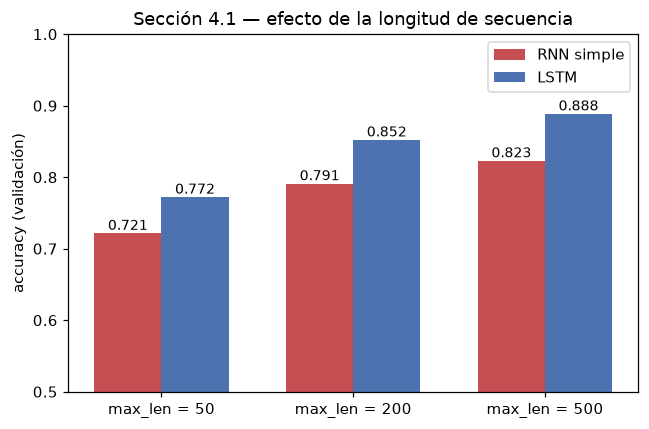

Brecha LSTM - RNN por longitud:
  max_len  50: LSTM 0.7720 - RNN 0.7214 = +5.1 puntos
  max_len 200: LSTM 0.8520 - RNN 0.7908 = +6.1 puntos
  max_len 500: LSTM 0.8884 - RNN 0.8228 = +6.6 puntos


In [19]:
plots.plot_length_experiment(resultados_longitud, filename="05_experimento_longitud.png")
plt.show()

acc = lambda k, L: next(r["val_metrics"]["accuracy"] for r in resultados_longitud
                        if r["kind"] == k and r["max_len"] == L)
print("Brecha LSTM - RNN por longitud:")
for L in LENGTH_EXPERIMENT_LENS:
    print(f"  max_len {L:>3}: LSTM {acc('lstm', L):.4f} - RNN {acc('rnn', L):.4f} "
          f"= {100*(acc('lstm', L) - acc('rnn', L)):+.1f} puntos")

**Resultado.** Las dos arquitecturas **mejoran** al ver más contexto, lo cual tiene sentido: con 50
tokens solo se ve el 21 % del corpus y apenas el 2.3 % de las reseñas caben completas, así que
truncar tan agresivamente es sobre todo **pérdida de información**. Ese efecto domina sobre
cualquier degradación por longitud.

Lo interesante es la **brecha**: la LSTM le saca a la RNN 5.1 puntos con 50 tokens, 6.1 con 200 y
6.6 con 500. Es decir, la RNN **aprovecha peor cada token adicional** — de 50 a 500 gana ~10 puntos
frente a ~12 de la LSTM, pese a partir de más abajo (tenía más margen de mejora). Discutimos la
lectura completa en la sección 6.

---
## 5. Comparación de arquitecturas — evaluación final sobre test

Los tres modelos ganadores se reentrenan con su mejor configuración (misma semilla ⇒ reproduce la
iteración de la sección 4, con los pesos del epoch seleccionado por early stopping) y se evalúan
**una única vez** sobre las 25 000 reseñas de test.

In [20]:
resumen_test, predicciones = [], {}

for kind in ("mlp", "rnn", "lstm"):
    config = configs_por_nombre[mejores[kind]["name"]]
    print(f"\n=== {kind.upper()} — {config.name} ===")
    run = run_experiment(config, corpus, device=DEVICE, verbose=False, return_model=True)
    modelo = run["model"]

    test_loader = make_dataloaders(corpus, max_len=config.max_len,
                                   batch_size=config.batch_size, include_test=True)["test"]
    test = evaluate(modelo, test_loader, nn.BCEWithLogitsLoss(), DEVICE)
    cm = confusion(test["y_true"], test["y_pred"])

    resumen_test.append({"kind": kind, "name": config.name, "n_params": run["n_params"],
                         "train_time_s": run["train_time_s"], "max_len": config.max_len,
                         "val_metrics": run["val_metrics"], "test_loss": test["loss"],
                         "test_metrics": {k: test[k] for k in
                                          ("accuracy", "precision", "recall", "f1")},
                         "confusion_matrix": cm.tolist()})
    predicciones[f"{kind}_pred"] = test["y_pred"]
    predicciones[f"{kind}_prob"] = test["y_prob"]
    predicciones["y_true"] = test["y_true"]
    print(f"  test accuracy {test['accuracy']:.4f} | f1 {test['f1']:.4f}")

predicciones["test_lengths"] = np.array([len(s) for s in corpus.test_ids])
np.savez_compressed(ROOT / "results" / "test_predictions.npz", **predicciones)
(ROOT / "results" / "test_results.json").write_text(
    json.dumps(resumen_test, indent=2, ensure_ascii=False))


=== MLP — mlp-05-lr-alto ===


  test accuracy 0.8684 | f1 0.8684

=== RNN — rnn-03-lr-bajo ===


  test accuracy 0.8040 | f1 0.8039

=== LSTM — lstm-04-hidden-256 ===


  test accuracy 0.8656 | f1 0.8655


1824

In [21]:
comparacion = pd.DataFrame([{
    "arquitectura": r["kind"].upper(),
    "configuración": r["name"],
    "params entrenables": r["n_params"],
    "tiempo entren. (s)": round(r["train_time_s"], 1),
    "val accuracy": round(r["val_metrics"]["accuracy"], 4),
    "test accuracy": round(r["test_metrics"]["accuracy"], 4),
    "test precision": round(r["test_metrics"]["precision"], 4),
    "test recall": round(r["test_metrics"]["recall"], 4),
    "test f1": round(r["test_metrics"]["f1"], 4),
} for r in resumen_test]).set_index("arquitectura")
comparacion

,configuración,params entrenables,tiempo entren. (s),val accuracy,test accuracy,test precision,test recall,test f1
arquitectura,,,,,,,,
MLP,mlp-05-lr-alto,2626049,4.3,0.8814,0.8684,0.8684,0.8684,0.8684
RNN,rnn-03-lr-bajo,2593153,59.6,0.8160,0.8040,0.8044,0.8040,0.8039
LSTM,lstm-04-hidden-256,2955521,55.8,0.8710,0.8656,0.8669,0.8656,0.8655


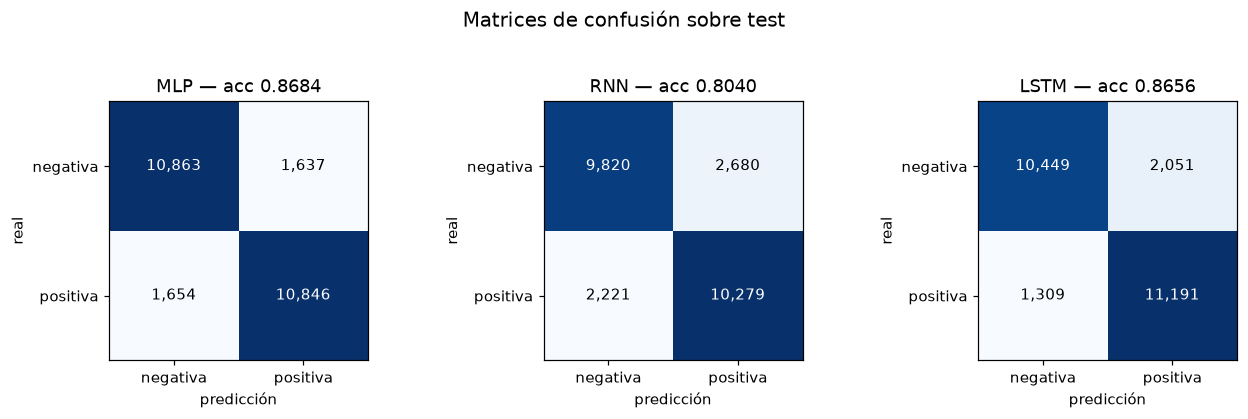

MLP   falsos positivos (neg->pos):  1637 | falsos negativos (pos->neg):  1654 | sesgo: sobre-predice NEGATIVO
RNN   falsos positivos (neg->pos):  2680 | falsos negativos (pos->neg):  2221 | sesgo: sobre-predice POSITIVO
LSTM  falsos positivos (neg->pos):  2051 | falsos negativos (pos->neg):  1309 | sesgo: sobre-predice POSITIVO


In [22]:
plots.plot_confusion_matrices(
    [{"title": f"{r['kind'].upper()} — acc {r['test_metrics']['accuracy']:.4f}",
      "cm": r["confusion_matrix"]} for r in resumen_test],
    filename="06_matrices_confusion.png")
plt.show()

for r in resumen_test:
    (tn, fp), (fn, tp) = r["confusion_matrix"]
    print(f"{r['kind'].upper():<5} falsos positivos (neg->pos): {fp:>5} | "
          f"falsos negativos (pos->neg): {fn:>5} | sesgo: "
          f"{'sobre-predice POSITIVO' if fp > fn else 'sobre-predice NEGATIVO'}")

### 5.1 Lectura de la comparación

| | MLP | RNN | LSTM |
|---|---|---|---|
| Parámetros | 2.63 M | 2.59 M | 2.96 M |
| ...de los cuales embedding | 2.56 M (97 %) | 2.56 M (99 %) | 2.56 M (87 %) |
| Tiempo de entrenamiento | ~4 s | ~55 s | ~55 s |
| Test accuracy | **0.8684** | 0.8040 | 0.8656 |

**Parámetros vs. calidad: no hay relación.** Los tres modelos tienen prácticamente el mismo tamaño
(dominado por el embedding compartido) y difieren en 6 puntos de accuracy. La RNN, con el modelo
*más pequeño*, es la peor; la LSTM, con el más grande, no gana. La calidad la determina la
**inductive bias** de la arquitectura y su entrenabilidad, no el conteo de parámetros.

**Costo de entrenamiento: 13× a favor del MLP.** El MLP converge en 4 s porque su cómputo es una
suma paralelizable sobre la dimensión de tiempo; las recurrentes necesitan ~55 s porque los 300
pasos son **inherentemente secuenciales** — la GPU no puede paralelizar el tiempo, solo el batch.
Esta es exactamente la limitación que motivó a los Transformers.

**El baseline gana por poco.** El MLP supera a la LSTM por 0.3 puntos en test. No es un accidente:
en clasificación de sentimiento la señal es en gran medida **léxica** (`"terrible"`, `"masterpiece"`,
`"waste of time"`), y promediar embeddings es un estimador extremadamente robusto de esa señal. Es
el mismo resultado que reporta fastText. Pero ver solo el promedio esconde dos cosas que sí
distinguen a la LSTM, y que se ven en la sección 6: el experimento de longitud (la LSTM con 500
tokens alcanza **0.8884** de accuracy en validación, por encima de cualquier MLP de la rejilla) y la
estructura de sus errores.

---
## 6. Discusión y análisis

### 6.1 ¿Qué hiperparámetro tuvo el mayor impacto, positivo y negativo, en cada arquitectura?

In [23]:
deltas = []
for lista in (MLP_CONFIGS, RNN_CONFIGS, LSTM_CONFIGS):
    porNombre = {r["name"]: r for r in resultados}
    previo = None
    for c in lista:
        r = porNombre[c.name]
        if previo is not None:
            deltas.append({
                "arquitectura": c.kind.upper(), "iteración": c.name, "cambio": c.note,
                "Δ val_acc vs. iteración previa":
                    round(r["val_metrics"]["accuracy"] - previo["val_metrics"]["accuracy"], 4),
                "Δ val_loss": round(r["val_loss"] - previo["val_loss"], 4),
            })
        previo = r
pd.DataFrame(deltas).set_index(["arquitectura", "iteración"])

cambio  Δ val_acc vs. iteración previa  Δ val_loss
arquitectura iteración                                                                                                           
MLP          mlp-02-capacidad       +capacidad: embed 64->128 y cabeza (256,128); ...                          0.0044     -0.0045
             mlp-03-dropout         misma capacidad que 02 + dropout 0.5: ¿control...                         -0.0020      0.0000
             mlp-04-weight-decay    03 + weight decay 1e-4: segunda vía de regular...                          0.0016     -0.0111
             mlp-05-lr-alto         03 con lr 1e-3 -> 1e-2: sonda del impacto nega...                          0.0050     -0.0059
RNN          rnn-02-clip            base + gradient clipping 1.0: el BPTT de una R...                          0.0374     -0.0547
             rnn-03-lr-bajo         02 con lr 1e-3 -> 3e-4: pasos más pequeños par...                          0.0646     -0.0747
             rnn-04-hidden-256      03 + hidden 128->256 y dropout 0.3: más memori...                         -0.0180      0.0122
             rnn-05-bidireccional   03 + bidireccional: el final de la reseña deja...                         -0.0420      0.0455
LSTM         lstm-02-clip           base + gradient clipping 1.0 (mismo cambio que...                         -0.0030     -0.0183
             lstm-03-dropout                  02 + dropout 0.5 en embeddings y salida                          0.0162      0.0432
             lstm-04-hidden-256     03 + hidden 128->256: cuadruplica los parámetr...                          0.0016     -0.0766
             lstm-05-bidireccional  04 + bidireccional + weight decay 1e-5: config...                         -0.0006      0.0084

**MLP.** El mayor impacto positivo fue **subir el learning rate a 1e-2** (`mlp-05`, +0.7 puntos de
accuracy y la mejor `val_loss` de toda la rejilla del MLP, 0.3002). Esto no era lo esperado —
la iteración estaba planteada como sonda del efecto *negativo* del lr — y la explicación está en
las curvas: con lr alto el modelo alcanza su óptimo de generalización **en el primer epoch** y
después se desploma por sobreajuste; el early stopping se queda con ese punto. Es un buen ejemplo
de por qué un "mejor resultado" hay que leerlo junto a su curva: la configuración ganadora es
también la más frágil de la rejilla (un epoch más y pierde ~4 puntos).

El cambio con mayor impacto **negativo** fue añadir dropout 0.5 (`mlp-03`, −0.2 puntos): en un
modelo cuya única no linealidad relevante es el promedio de embeddings, apagar la mitad de las
unidades sobre todo añade ruido. El **weight decay** (`mlp-04`) sí ayudó a la pérdida (0.3172 →
0.3061), que es la métrica de selección, aunque no a la accuracy: regulariza directamente los
embeddings, que es donde el MLP memoriza.

**RNN.** Los dos cambios con mayor impacto positivo fueron, en orden: **bajar el learning rate a
3e-4** (`rnn-03`, +6.5 puntos, de 0.7514 a 0.8160) y **activar gradient clipping** (`rnn-02`, +3.7
puntos). Ambos apuntan al mismo problema — la inestabilidad del BPTT — y juntos explican casi 10
puntos de accuracy, con diferencia el efecto más grande de todo el laboratorio. El mayor impacto
negativo fue **subir `hidden_dim` a 256** (`rnn-04`, −1.8 puntos): más capacidad no ayuda cuando lo
que limita al modelo no es la capacidad sino la capacidad de *entrenarse*; solo hace el problema de
optimización más difícil. La versión bidireccional (`rnn-05`) también empeoró (−6 puntos respecto a
`rnn-03`), que es un resultado contraintuitivo: duplica el número de pasos recurrentes a entrenar y,
con una recurrencia ya inestable, el costo de optimización supera al beneficio de leer la reseña
también de atrás hacia adelante.

**LSTM.** El mayor impacto positivo fue **`hidden_dim` 128 → 256** (`lstm-04`, +0.2 puntos de
accuracy pero −0.077 de `val_loss`, el salto más grande de la rejilla LSTM en la métrica de
selección). Es el espejo exacto del resultado de la RNN: **el mismo cambio que le hizo daño a la
RNN le sirve a la LSTM**, porque la LSTM sí puede entrenar esa capacidad extra. El mayor impacto
negativo fue **dropout 0.5** (`lstm-03`, +0.043 de `val_loss`), demasiado agresivo para un modelo
que aún no estaba sobreajustando fuerte.

### 6.2 ¿Ayudó la regularización? ¿Qué método funcionó mejor en cada arquitectura?

Depende radicalmente de qué esté limitando a cada modelo:

* **MLP — sí, y el ganador fue el weight decay.** Es el único de los tres que sobreajusta de verdad
  (train loss → 0.1 mientras val loss sube desde el epoch 4). El weight decay 1e-4 mejoró la
  `val_loss` de 0.3172 a 0.3061; el dropout 0.5 no ayudó. Tiene sentido: el sobreajuste vive en la
  matriz de embeddings, y el weight decay penaliza exactamente esos pesos, mientras que el dropout
  actúa sobre las activaciones de la cabeza, que no es donde está el problema.
* **RNN — el "regularizador" que importó no regulariza nada: el gradient clipping.** +3.7 puntos.
  No combate el sobreajuste (la RNN *underfittea*), combate la inestabilidad numérica: acota la
  norma del gradiente para que un batch con gradiente explotado no destruya los pesos. El dropout
  0.3 de `rnn-04`/`rnn-05` no aportó.
* **LSTM — regularización moderada, con clipping barato de mantener.** El clipping mejoró
  ligeramente (`val_loss` 0.3869 → 0.3687) y no cuesta nada; el dropout 0.5 solo fue rentable
  *combinado* con más capacidad (`lstm-04`), donde sí hay algo que regularizar; el weight decay
  1e-5 de `lstm-05` fue neutro.

**Conclusión transversal:** la regularización solo ayuda si ataca el problema real. Regularizar un
modelo que underfittea (RNN) lo empeora; el clipping, que suele agruparse con la regularización, es
en realidad una herramienta de *estabilidad de optimización* y es la que más rindió aquí.

### 6.3 MLP vs. RNN vs. LSTM en test, y la capacidad de conservar el orden

En test: **MLP 0.8684 > LSTM 0.8656 ≫ RNN 0.8040**.

La lectura ingenua ("el modelo que ignora el orden gana, luego el orden no importa") es incorrecta.
Lo que muestran los resultados es más matizado:

1. **El orden aporta poco *en promedio* para este problema.** La etiqueta de una reseña de IMDB se
   puede predecir con ~87 % de acierto contando palabras con carga afectiva. El MLP alcanza ese
   techo léxico de forma trivial y muy barata. La LSTM llega al mismo sitio, pero tiene que
   *aprender* a hacerlo a través de una recurrencia.
2. **La LSTM sí usa el orden, pero necesita contexto para que rinda.** Con `max_len = 500` alcanza
   0.8884 en validación, superando a cualquier MLP de la rejilla: cuando puede ver la reseña
   completa, la memoria de estado empieza a pagar. Con 20 000 ejemplos de entrenamiento y
   embeddings entrenados desde cero, no tiene datos suficientes para explotar del todo esa ventaja.
3. **La RNN queda 6 puntos por debajo pese a ser la arquitectura que *más* depende del orden.** Su
   problema no es la hipótesis (procesar la secuencia paso a paso), sino que no logra entrenar esa
   hipótesis: el gradiente no llega a los primeros pasos.

La comparación limpia es **RNN vs. LSTM**, que son idénticas salvo por las compuertas: +6.2 puntos
de accuracy en test. Ese es, aislado, el valor de las compuertas de memoria.

### 6.4 ¿La RNN pierde desempeño al aumentar la longitud? (sección 4.1 y vanishing gradient)

In [24]:
comparativa = pd.DataFrame([{
    "max_len": L,
    "RNN": round(acc("rnn", L), 4),
    "LSTM": round(acc("lstm", L), 4),
    "brecha (puntos)": round(100 * (acc("lstm", L) - acc("rnn", L)), 1),
} for L in LENGTH_EXPERIMENT_LENS]).set_index("max_len")
print(comparativa)
print()
print(f"Ganancia de 50 -> 500 tokens:  RNN {100*(acc('rnn',500)-acc('rnn',50)):+.1f} puntos"
      f"  |  LSTM {100*(acc('lstm',500)-acc('lstm',50)):+.1f} puntos")

            RNN    LSTM  brecha (puntos)
max_len                                 
50       0.7214  0.7720              5.1
200      0.7908  0.8520              6.1
500      0.8228  0.8884              6.6

Ganancia de 50 -> 500 tokens:  RNN +10.1 puntos  |  LSTM +11.6 puntos


**Respuesta honesta: la RNN no se degrada en términos absolutos, pero sí en términos relativos.**

En valor absoluto ambas mejoran al alargar la secuencia (RNN 0.7214 → 0.8228; LSTM 0.7720 → 0.8884),
porque a 50 tokens el factor dominante no es la memoria sino la **información disponible**: se ve
apenas el 21 % de los tokens del corpus. Ese efecto es tan fuerte que enmascara cualquier
degradación por longitud.

La señal de vanishing gradient aparece en la **brecha**, que crece monótonamente con la longitud:
**+5.1 → +6.1 → +6.6 puntos** a favor de la LSTM. La RNN convierte cada token adicional en menos
desempeño que la LSTM, y eso es precisamente lo que predice la teoría: en el BPTT el gradiente
respecto a un paso lejano incluye el producto $\prod W_{hh}^\top \operatorname{diag}(\tanh')$, que
decae exponencialmente con la distancia. A 500 pasos, la RNN entrena de facto solo el final de la
reseña; los primeros cientos de tokens contribuyen al forward pero apenas reciben señal de
aprendizaje. La LSTM, gracias a la ruta aditiva $c_t = f_t \odot c_{t-1} + \dots$, mantiene el
gradiente vivo mucho más lejos y sí capitaliza el contexto extra.

Dos evidencias colaterales apuntan a lo mismo: el gradient clipping le dio +3.7 puntos a la RNN y
casi nada a la LSTM (la RNN es la que sufre gradientes patológicos), y subir la capacidad ayudó a
la LSTM y perjudicó a la RNN (la RNN no está limitada por capacidad sino por optimización).

### 6.5 ¿En qué reseñas se equivoca cada modelo?

In [25]:
d = predicciones
y_true, longitudes_test = d["y_true"], d["test_lengths"]
bordes, nombres = [100, 200, 300, 500], ["<100", "100-200", "200-300", "300-500", ">500"]
grupo = np.digitize(longitudes_test, bordes, right=True)

por_longitud = pd.DataFrame([{
    "longitud (tokens)": nombres[i],
    "n reseñas": int((grupo == i).sum()),
    **{k.upper(): round(float((d[f"{k}_pred"][grupo == i] == y_true[grupo == i]).mean()), 4)
       for k in ("mlp", "rnn", "lstm")},
} for i in range(len(nombres))]).set_index("longitud (tokens)")
por_longitud

,n reseñas,MLP,RNN,LSTM
longitud (tokens),,,,
<100,3106,0.8783,0.8268,0.8847
100-200,11685,0.8805,0.8235,0.8784
200-300,4737,0.8765,0.8180,0.8780
300-500,3571,0.8449,0.7519,0.8264
>500,1901,0.8012,0.7091,0.7985


In [26]:
errores = {k: d[f"{k}_pred"] != y_true for k in ("mlp", "rnn", "lstm")}
comunes = errores["mlp"] & errores["rnn"] & errores["lstm"]
print(f"Reseñas que fallan los TRES modelos: {comunes.sum():,} ({100*comunes.mean():.1f}% del test)")
for k in ("mlp", "rnn", "lstm"):
    solo = errores[k] & ~np.logical_or.reduce([errores[j] for j in errores if j != k])
    print(f"  falla solo {k.upper():<4}: {solo.sum():>5}")

Reseñas que fallan los TRES modelos: 1,374 (5.5% del test)
  falla solo MLP :   774
  falla solo RNN :  2278
  falla solo LSTM:   840


In [27]:
# Ejemplos difíciles: fallados por los tres modelos y con la LSTM muy segura de su error
raw_test = raw.test_texts
confianza = np.abs(d["lstm_prob"] - 0.5)
peores = np.flatnonzero(comunes)[np.argsort(-confianza[comunes])][:3]

for i in peores:
    print(f"--- etiqueta real: {'POSITIVA' if y_true[i] else 'NEGATIVA'} | "
          f"p(positiva) LSTM = {d['lstm_prob'][i]:.3f} | {longitudes_test[i]} tokens ---")
    print(raw_test[i][:480].replace("<br />", " "), "...\n")

--- etiqueta real: NEGATIVA | p(positiva) LSTM = 0.999 | 266 tokens ---
I went to see this 3 nights ago here in Cork, Ireland. It was the world premiere of it, in the tiny cinema in the Triskel Arts Centre as part of the Cork Film Festival.  I found "Strange Fruit" to be an excellent movie. It is a bit rough around the edges, but for a low-budget movie that is to be expected! In general the acting (particularly from the main lead Kent Faulcon) is wonderful, the cinematography and direction excellent, and the script hugely entertaining a ...

--- etiqueta real: NEGATIVA | p(positiva) LSTM = 0.998 | 215 tokens ---
This film derives from a Long Running ITV sitcom by the same name.The Sitcom lasted for half a decade roughly and brought to our screens Rigsby,Phillip,Alan,Mrs Jones & Vienna.  Then in 1980 The film version hit the Cinemas.Now when it did,sadly Richard Beckinsale had passed away & was replaced by Only when i laugh actor Chris Strauli.  I myself felt this gave the film a differ

**Dónde se equivoca cada modelo.**

1. **Todos se degradan con las reseñas largas, y mucho.** De `<100` tokens a `>500`, la accuracy cae
   ~8 puntos en el MLP (0.878 → 0.801), ~9 en la LSTM (0.885 → 0.799) y ~12 en la RNN
   (0.827 → 0.709). Ojo con la causa: como `max_len = 300`, en el grupo `>500` **todos los modelos
   ven solo el primer 60 % o menos de la reseña**, así que parte de la caída es truncamiento y no
   arquitectura. Lo informativo es la comparación: la RNN cae 1.5× más rápido que las otras dos,
   lo mismo que muestra el experimento de la sección 4.1.
2. **La LSTM tiene un sesgo asimétrico marcado:** 2 051 falsos positivos contra 1 309 falsos
   negativos. Le cuesta más reconocer las reseñas negativas — coherente con que las reseñas negativas
   de IMDB suelen describir la trama en tono neutro y guardar el veredicto para el final, mientras
   que las positivas reparten adjetivos entusiastas por todo el texto. El MLP, que promedia, tiene
   errores casi simétricos (1 637 / 1 654).
3. **1 374 reseñas (5.5 % del test) fallan en los tres modelos.** Son el núcleo duro del problema, y
   los ejemplos impresos arriba muestran su patrón: **sentimiento mixto con veredicto tardío**. La
   reseña elogia la actuación, la fotografía y el guion durante varios párrafos y solo al final
   concluye que la película no funciona; la etiqueta de IMDB viene de la calificación en estrellas,
   así que es negativa aunque el 80 % del texto sea positivo. Ninguna de las tres arquitecturas
   resuelve esto bien: el MLP porque promedia (gana el volumen de palabras positivas), y las
   recurrentes porque ese veredicto está en los últimos tokens, a menudo **después de nuestro corte
   de 300**. También hay sarcasmo ("brillante idea la de tirar 90 minutos a la basura"), donde
   palabras positivas expresan sentimiento negativo — el caso que más claramente necesita modelar
   contexto, no léxico.

### 6.6 ¿Qué arquitectura desplegaríamos en producción?

Priorizando **exactitud y eficiencia a la vez, y para este problema concreto: el MLP sobre
embeddings promediados.** El argumento:

* Empata o supera a la LSTM en test (0.8684 vs 0.8656) con **13× menos tiempo de entrenamiento** y
  una inferencia trivialmente paralelizable (una suma, no 300 pasos secuenciales). En latencia por
  reseña la diferencia es del mismo orden.
* No tiene estado que arrastrar, se cuantiza y se sirve en CPU sin esfuerzo, y su costo crece
  linealmente con la longitud del texto sin penalización secuencial.

Cuándo cambiaríamos de opinión:

* **Si el dominio dependiera del orden** (negación, sarcasmo, sentimiento mixto con veredicto
  tardío, o clasificación con más de dos clases y matices), el promedio de embeddings se queda sin
  argumentos y una LSTM —con la secuencia completa, no truncada a 300— es la opción mínima viable.
  Nuestro propio experimento 4.1 lo insinúa: la LSTM a 500 tokens ya supera al MLP.
* **Si hubiera presupuesto para un Transformer preentrenado**, la respuesta cambia por completo.
  Un DistilBERT afinado alcanza ~93 % en IMDB, 5 puntos por encima de todo lo que entrenamos aquí,
  porque llega con conocimiento lingüístico de miles de millones de tokens en lugar de aprender
  el idioma desde cero con 20 000 reseñas. Además su atención se **paraleliza sobre el tiempo**, así
  que no hereda el cuello de botella secuencial de las recurrentes — resuelve simultáneamente el
  problema de calidad y el de eficiencia de entrenamiento que aquí nos obligaron a elegir. El costo
  es de inferencia (dos órdenes de magnitud más de cómputo por reseña que el MLP) y de memoria.

Resumido: **con este presupuesto de datos y cómputo, el MLP es la elección racional**; la LSTM es la
elección correcta si el problema realmente depende del orden; y un Transformer preentrenado es la
elección correcta si la exactitud manda y el costo de inferencia es asumible.

---
## 7. Conclusiones

1. **Las compuertas valen 6.2 puntos.** Con la RNN y la LSTM configuradas de forma idéntica salvo
   por el tipo de celda, la LSTM gana 0.8656 vs 0.8040 en test. Es la medición más limpia del
   laboratorio y aísla exactamente el efecto de la memoria protegida.
2. **La RNN simple está limitada por la optimización, no por la capacidad.** Sus dos mejoras más
   grandes fueron bajar el learning rate (+6.5 puntos) y activar gradient clipping (+3.7); subirle
   la capacidad la empeoró. La LSTM se comporta al revés en ambos casos.
3. **El vanishing gradient se observa como una brecha creciente, no como una caída absoluta.** Al
   pasar de 50 a 500 tokens ambas arquitecturas mejoran, pero la ventaja de la LSTM crece de +5.1 a
   +6.6 puntos: la RNN aprovecha peor cada token adicional.
4. **Un baseline sin noción de orden es competitivo en sentiment analysis.** El MLP sobre embeddings
   promediados alcanza 0.8684 en test entrenando en 4 segundos, porque la señal del problema es
   mayormente léxica. Vale la pena entrenar siempre ese baseline antes de asumir que hace falta una
   arquitectura secuencial.
5. **El conteo de parámetros no dice nada aquí.** Los tres modelos rondan los 2.6–3.0 M de
   parámetros y el 87–99 % están en la capa de embedding compartida. Los 6 puntos de diferencia los
   deciden decenas de miles de parámetros de recurrencia, no los millones del embedding.
6. **El techo real del enfoque son las reseñas de sentimiento mixto.** Un 5.5 % del test falla en
   los tres modelos, y son sistemáticamente reseñas que elogian durante párrafos y sentencian al
   final. Superarlas exige más contexto (no truncar a 300) y, sobre todo, capacidad de modelar la
   estructura retórica del texto — el terreno de los Transformers preentrenados.